In [0]:
import os
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mlflow
import mlflow.sklearn

from mlflow import MlflowClient
from mlflow.models import infer_signature

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


In [0]:
EXPERIMENT_NAME = "/Shared/Football_MLflow_Experiment"

mlflow.set_tracking_uri("databricks")
mlflow.set_registry_uri("databricks-uc")
mlflow.set_experiment(EXPERIMENT_NAME)

print("MLflow tracking URI:", mlflow.get_tracking_uri())
print("MLflow registry URI:", mlflow.get_registry_uri())
print("Experiment:", EXPERIMENT_NAME)

MLflow tracking URI: databricks
MLflow registry URI: databricks-uc
Experiment: /Shared/Football_MLflow_Experiment


In [0]:
DATA_DIRECTORY = "/Volumes/workspace/default/football_data"

TRAIN_PATH = (
    f"{DATA_DIRECTORY}/football_train.csv"
)

TEST_PATH = (
    f"{DATA_DIRECTORY}/football_test.csv"
)

CHAMPION_INFO_PATH = (
    f"{DATA_DIRECTORY}/champion_run_info.csv"
)

CHAMPION_REGISTRATION_PATH = (
    f"{DATA_DIRECTORY}/champion_registration_info.csv"
)

CHALLENGER_INFO_PATH = (
    f"{DATA_DIRECTORY}/challenger_run_info.csv"
)

CHALLENGER_RESULTS_PATH = (
    f"{DATA_DIRECTORY}/challenger_test_predictions.csv"
)

CHALLENGER_SUMMARY_PATH = (
    f"{DATA_DIRECTORY}/challenger_evaluation_summary.csv"
)

TARGET_COLUMN = "match_result"

REGISTERED_MODEL_NAME = (
    "workspace.default.football_match_result_model"
)

CHAMPION_ALIAS = "champion"

RANDOM_STATE = 42

PRIMARY_METRIC = "test_f1_macro"

print("Configuration completed.")

Configuration completed.


In [0]:
required_files = [
    TRAIN_PATH,
    TEST_PATH,
    CHAMPION_INFO_PATH,
    CHAMPION_REGISTRATION_PATH
]

missing_files = [
    file_path
    for file_path in required_files
    if not os.path.exists(file_path)
]

assert not missing_files, (
    "The following required files are missing: "
    f"{missing_files}"
)

print("All required input files are available.")

All required input files are available.


In [0]:
champion_info_df = pd.read_csv(
    CHAMPION_INFO_PATH
)

champion_registration_df = pd.read_csv(
    CHAMPION_REGISTRATION_PATH
)

print("Current Champion information:")
display(champion_info_df)

print("Current Champion registration:")
display(champion_registration_df)

Current Champion information:


model_role,algorithm,run_id,model_uri,primary_metric,primary_metric_value,test_accuracy,test_precision_macro,test_recall_macro,test_f1_macro,test_f1_weighted,training_rows,testing_rows,training_time_seconds,max_depth,min_samples_split,min_samples_leaf,class_weight,removed_columns_path,registration_status,alias_status,registered_model_name,registered_model_version,registered_model_alias,alias_model_uri
champion,DecisionTreeClassifier,36362b3ba7c6483f8f3f3e9d22c555da,models:/m-7f4fd69605ed465f9a37b8737f96456c,test_f1_macro,0.3407115240453506,0.35575,0.5227480171428843,0.4249912752465563,0.3407115240453506,0.3219326636027983,15999,4000,0.1623985767364502,3,20,10,balanced,/Volumes/workspace/default/football_data/champion_removed_columns.json,READY,assigned,workspace.default.football_match_result_model,2,champion,models:/workspace.default.football_match_result_model@champion


Current Champion registration:


registered_model_name,registered_model_version,alias,alias_model_uri,algorithm,run_id,source_model_uri,primary_metric,primary_metric_value,registration_status,alias_status,model_role,previous_champion_version,previous_champion_run_id
workspace.default.football_match_result_model,2,champion,models:/workspace.default.football_match_result_model@champion,DecisionTreeClassifier,36362b3ba7c6483f8f3f3e9d22c555da,models:/m-7f4fd69605ed465f9a37b8737f96456c,test_f1_macro,0.3407115240453506,READY,assigned,champion,1,59ac34bdab614aa0b3ee63b9a935f941


In [0]:
assert len(champion_info_df) == 1, (
    "champion_run_info.csv must contain exactly one row."
)

champion_record = champion_info_df.iloc[0]

champion_algorithm = str(
    champion_record["algorithm"]
)

champion_run_id = str(
    champion_record["run_id"]
)

champion_macro_f1 = float(
    champion_record["primary_metric_value"]
)

champion_version = str(
    champion_record["registered_model_version"]
)

assert champion_algorithm == "DecisionTreeClassifier", (
    "Notebook 6 expected the current Champion to be "
    f"DecisionTreeClassifier, but found {champion_algorithm}."
)

print("Current Champion algorithm:", champion_algorithm)
print("Current Champion run ID:", champion_run_id)
print("Current Champion version:", champion_version)

print(
    "Current Champion Macro F1:",
    round(champion_macro_f1, 4)
)

Current Champion algorithm: DecisionTreeClassifier
Current Champion run ID: 36362b3ba7c6483f8f3f3e9d22c555da
Current Champion version: 2
Current Champion Macro F1: 0.3407


In [0]:
client = MlflowClient()

alias_model_version = (
    client.get_model_version_by_alias(
        name=REGISTERED_MODEL_NAME,
        alias=CHAMPION_ALIAS
    )
)

resolved_champion_version = str(
    alias_model_version.version
)

resolved_champion_run_id = str(
    alias_model_version.run_id
)

print("Alias-resolved Champion version:", resolved_champion_version)
print("Alias-resolved Champion run ID:", resolved_champion_run_id)

Alias-resolved Champion version: 2
Alias-resolved Champion run ID: 36362b3ba7c6483f8f3f3e9d22c555da


In [0]:
assert resolved_champion_version == champion_version, (
    "The champion alias does not point to the version "
    "recorded in champion_run_info.csv."
)

assert resolved_champion_run_id == champion_run_id, (
    "The champion alias run ID does not match the "
    "recorded Champion run ID."
)

print("Champion alias verification passed.")

Champion alias verification passed.


In [0]:
train_df = pd.read_csv(
    TRAIN_PATH
)

test_df = pd.read_csv(
    TEST_PATH
)

print("Training shape:", train_df.shape)
print("Testing shape:", test_df.shape)

print("Training rows:", len(train_df))
print("Testing rows:", len(test_df))

Training shape: (15999, 58)
Testing shape: (4000, 58)
Training rows: 15999
Testing rows: 4000


In [0]:
assert TARGET_COLUMN in train_df.columns, (
    f"{TARGET_COLUMN} is missing from the training dataset."
)

assert TARGET_COLUMN in test_df.columns, (
    f"{TARGET_COLUMN} is missing from the test dataset."
)

assert len(train_df) == 15999, (
    f"Expected 15999 training rows, found {len(train_df)}."
)

assert len(test_df) == 4000, (
    f"Expected 4000 test rows, found {len(test_df)}."
)

assert list(train_df.columns) == list(test_df.columns), (
    "Training and test dataset columns are different."
)

print("Frozen dataset validation passed.")

Frozen dataset validation passed.


In [0]:
print("Training target distribution:")

training_target_distribution = (
    train_df[TARGET_COLUMN]
    .value_counts()
    .to_frame("count")
)

training_target_distribution[
    "proportion"
] = (
    training_target_distribution["count"]
    / len(train_df)
)

display(training_target_distribution)

Training target distribution:


count,proportion
7254,0.4534033377086068
4894,0.3058941183823989
3851,0.24070254390899432


In [0]:
LEAKAGE_COLUMNS = [
    "home_score",
    "away_score"
]

available_leakage_columns = [
    column
    for column in LEAKAGE_COLUMNS
    if column in train_df.columns
]

train_df = train_df.drop(
    columns=available_leakage_columns,
    errors="ignore"
)

test_df = test_df.drop(
    columns=available_leakage_columns,
    errors="ignore"
)

print(
    "Leakage columns removed:",
    available_leakage_columns
)

Leakage columns removed: []


In [0]:
X_train = train_df.drop(
    columns=[TARGET_COLUMN]
).copy()

y_train = train_df[
    TARGET_COLUMN
].copy()

X_test = test_df.drop(
    columns=[TARGET_COLUMN]
).copy()

y_test = test_df[
    TARGET_COLUMN
].copy()

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (15999, 57)
X_test shape: (4000, 57)
y_train shape: (15999,)
y_test shape: (4000,)


In [0]:
missing_ratios = X_train.isnull().mean()

columns_to_remove = missing_ratios[
    missing_ratios >= 0.95
].index.tolist()

X_train = X_train.drop(
    columns=columns_to_remove,
    errors="ignore"
)

X_test = X_test.drop(
    columns=columns_to_remove,
    errors="ignore"
)

print(
    "Columns removed because of at least "
    "95% missing data:"
)

print(columns_to_remove)

print(
    "Remaining feature count:",
    X_train.shape[1]
)

Columns removed because of at least 95% missing data:
['season_year', 'Interceptions_Home', 'Interceptions_Host', 'Clearances_Completed_Home', 'Clearances_Completed_Host', 'Pass_Success_per_Home', 'Pass_Success_per_Host', 'Crosses_Completed_Home', 'Crosses_Completed_Host', 'Distance_Covered_(km)_Home', 'Distance_Covered_(km)_Host', 'capacity', 'attendance']
Remaining feature count: 44


In [0]:
assert list(X_train.columns) == list(X_test.columns), (
    "Training and testing feature columns are not aligned."
)

assert X_train.shape[1] == X_test.shape[1], (
    "Training and testing feature counts differ."
)

print("Training and testing features are aligned.")

Training and testing features are aligned.


In [0]:
numeric_features = X_train.select_dtypes(
    include=["number"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    exclude=["number"]
).columns.tolist()

print("Numeric feature count:", len(numeric_features))
print("Categorical feature count:", len(categorical_features))

print("\nCategorical features:")
print(categorical_features)

Numeric feature count: 38
Categorical feature count: 6

Categorical features:
['Country', 'League', 'home_team', 'away_team', 'referee', 'venue']


In [0]:
numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

print("Numeric preprocessing pipeline created.")

Numeric preprocessing pipeline created.


In [0]:
categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

print("Categorical preprocessing pipeline created.")

Categorical preprocessing pipeline created.


In [0]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numeric_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ],
    remainder="drop"
)

print("Combined preprocessor created.")

Combined preprocessor created.


In [0]:
challenger_classifier = LogisticRegression(
    penalty="l2",
    C=1.0,
    solver="lbfgs",
    max_iter=2000,
    class_weight=None,
    random_state=RANDOM_STATE
)

print("Challenger classifier:")
print(challenger_classifier)

Challenger classifier:
LogisticRegression(max_iter=2000, random_state=42)


In [0]:
challenger_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            challenger_classifier
        )
    ]
)

print("Logistic Regression Challenger pipeline created.")

Logistic Regression Challenger pipeline created.


In [0]:
training_start_time = time.time()

challenger_pipeline.fit(
    X_train,
    y_train
)

challenger_training_time = (
    time.time() - training_start_time
)

print("Logistic Regression Challenger trained successfully.")

print(
    "Training rows used:",
    len(X_train)
)

print(
    "Training time:",
    round(challenger_training_time, 2),
    "seconds"
)

Logistic Regression Challenger trained successfully.
Training rows used: 15999
Training time: 21.35 seconds


In [0]:
trained_logistic_regression = (
    challenger_pipeline.named_steps[
        "classifier"
    ]
)

print(
    "Iterations used per class:",
    trained_logistic_regression.n_iter_
)

print(
    "Maximum iterations allowed:",
    trained_logistic_regression.max_iter
)

if np.max(
    trained_logistic_regression.n_iter_
) < trained_logistic_regression.max_iter:

    print(
        "The Logistic Regression model converged "
        "within the allowed iterations."
    )

else:
    print(
        "Warning: The model may not have fully converged."
    )

Iterations used per class: [204]
Maximum iterations allowed: 2000
The Logistic Regression model converged within the allowed iterations.


In [0]:
prediction_start_time = time.time()

challenger_predictions = (
    challenger_pipeline.predict(
        X_test
    )
)

challenger_prediction_time = (
    time.time() - prediction_start_time
)

print(
    "Number of Challenger predictions:",
    len(challenger_predictions)
)

print(
    "Prediction time:",
    round(challenger_prediction_time, 4),
    "seconds"
)

Number of Challenger predictions: 4000
Prediction time: 0.0351 seconds


In [0]:
assert len(challenger_predictions) == 4000

assert len(challenger_predictions) == len(y_test)

print("Challenger prediction count validated.")

Challenger prediction count validated.


In [0]:
challenger_probabilities = (
    challenger_pipeline.predict_proba(
        X_test
    )
)

print(
    "Probability matrix shape:",
    challenger_probabilities.shape
)

Probability matrix shape: (4000, 3)


In [0]:
assert challenger_probabilities.shape[0] == 4000

assert np.allclose(
    challenger_probabilities.sum(axis=1),
    1.0,
    atol=1e-6
)

assert np.all(
    challenger_probabilities >= 0
)

assert np.all(
    challenger_probabilities <= 1
)

print("Challenger probabilities validated.")

Challenger probabilities validated.


In [0]:
def calculate_metrics(
    y_true,
    y_pred
):
    return {
        "test_accuracy": accuracy_score(
            y_true,
            y_pred
        ),
        "test_precision_macro": precision_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),
        "test_recall_macro": recall_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),
        "test_f1_macro": f1_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),
        "test_f1_weighted": f1_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0
        )
    }

In [0]:
challenger_metrics = calculate_metrics(
    y_test,
    challenger_predictions
)

print("=" * 65)
print("LOGISTIC REGRESSION CHALLENGER RESULTS")
print("=" * 65)

for metric_name, metric_value in (
    challenger_metrics.items()
):
    print(
        f"{metric_name}: "
        f"{metric_value:.4f}"
    )

LOGISTIC REGRESSION CHALLENGER RESULTS
test_accuracy: 0.6515
test_precision_macro: 0.6447
test_recall_macro: 0.6137
test_f1_macro: 0.6222
test_f1_weighted: 0.6435


In [0]:
print(
    classification_report(
        y_test,
        challenger_predictions,
        zero_division=0
    )
)

              precision    recall  f1-score   support

    Away Win       0.65      0.58      0.61      1223
        Draw       0.62      0.46      0.53       963
    Home Win       0.66      0.80      0.72      1814

    accuracy                           0.65      4000
   macro avg       0.64      0.61      0.62      4000
weighted avg       0.65      0.65      0.64      4000



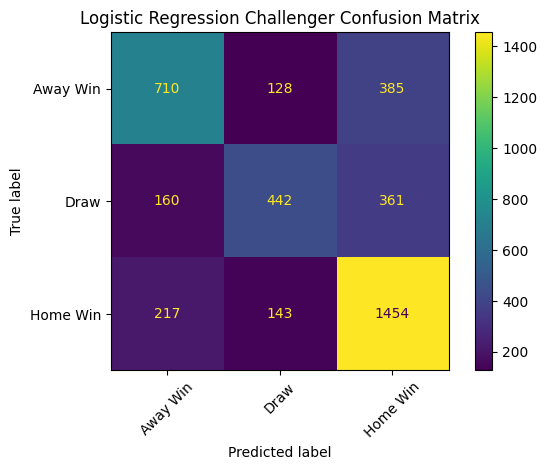

In [0]:
class_labels = sorted(
    y_test.unique().tolist()
)

challenger_confusion_matrix = confusion_matrix(
    y_test,
    challenger_predictions,
    labels=class_labels
)

confusion_display = ConfusionMatrixDisplay(
    confusion_matrix=challenger_confusion_matrix,
    display_labels=class_labels
)

confusion_display.plot(
    values_format="d"
)

plt.title(
    "Logistic Regression Challenger Confusion Matrix"
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [0]:
challenger_macro_f1 = float(
    challenger_metrics["test_f1_macro"]
)

macro_f1_improvement = (
    challenger_macro_f1
    - champion_macro_f1
)

relative_improvement_percentage = (
    macro_f1_improvement
    / champion_macro_f1
    * 100
)

challenger_outperforms_champion = (
    challenger_macro_f1
    > champion_macro_f1
)

print("=" * 65)
print("CHAMPION–CHALLENGER COMPARISON")
print("=" * 65)

print(
    "Champion algorithm:",
    champion_algorithm
)

print(
    "Champion Macro F1:",
    round(champion_macro_f1, 4)
)

print(
    "Challenger algorithm:",
    "LogisticRegression"
)

print(
    "Challenger Macro F1:",
    round(challenger_macro_f1, 4)
)

print(
    "Absolute improvement:",
    round(macro_f1_improvement, 4)
)

print(
    "Relative improvement:",
    round(relative_improvement_percentage, 2),
    "%"
)

print(
    "Challenger outperforms Champion:",
    challenger_outperforms_champion
)

CHAMPION–CHALLENGER COMPARISON
Champion algorithm: DecisionTreeClassifier
Champion Macro F1: 0.3407
Challenger algorithm: LogisticRegression
Challenger Macro F1: 0.6222
Absolute improvement: 0.2815
Relative improvement: 82.62 %
Challenger outperforms Champion: True


In [0]:
MINIMUM_REQUIRED_IMPROVEMENT = 0.0

promotion_eligible = (
    challenger_macro_f1
    > (
        champion_macro_f1
        + MINIMUM_REQUIRED_IMPROVEMENT
    )
)

if promotion_eligible:

    promotion_recommendation = (
        "PROMOTE_CHALLENGER"
    )

    print("=" * 65)
    print("CHALLENGER IS ELIGIBLE FOR PROMOTION")
    print("=" * 65)

    print(
        "The Logistic Regression Challenger "
        "has a higher Macro F1 than the "
        "Decision Tree Champion."
    )

    print(
        "Continue to Notebook 7 for registration "
        "and alias promotion."
    )

else:

    promotion_recommendation = (
        "KEEP_CURRENT_CHAMPION"
    )

    print("=" * 65)
    print("CHALLENGER IS NOT ELIGIBLE FOR PROMOTION")
    print("=" * 65)

    print(
        "The Logistic Regression Challenger "
        "did not exceed the current Champion."
    )

CHALLENGER IS ELIGIBLE FOR PROMOTION
The Logistic Regression Challenger has a higher Macro F1 than the Decision Tree Champion.
Continue to Notebook 7 for registration and alias promotion.


In [0]:
assert promotion_eligible, (
    "The Logistic Regression Challenger did not "
    "outperform the Decision Tree Champion. "
    "Review the data, preprocessing and model results "
    "before continuing to Notebook 7."
)

print(
    "Version 2 requirement satisfied: "
    "the Challenger is eligible for promotion."
)

Version 2 requirement satisfied: the Challenger is eligible for promotion.


In [0]:
comparison_df = pd.DataFrame(
    [
        {
            "model_role": "Champion",
            "algorithm": champion_algorithm,
            "test_f1_macro": champion_macro_f1,
            "registered_version": champion_version,
            "promotion_status": (
                "Current Champion"
            )
        },
        {
            "model_role": "Challenger",
            "algorithm": "LogisticRegression",
            "test_f1_macro": challenger_macro_f1,
            "registered_version": None,
            "promotion_status": (
                "Eligible for Promotion"
                if promotion_eligible
                else "Not Eligible"
            )
        }
    ]
)

display(comparison_df)

model_role,algorithm,test_f1_macro,registered_version,promotion_status
Champion,DecisionTreeClassifier,0.3407115240453506,2,Current Champion
Challenger,LogisticRegression,0.6222097633743984,null,Eligible for Promotion


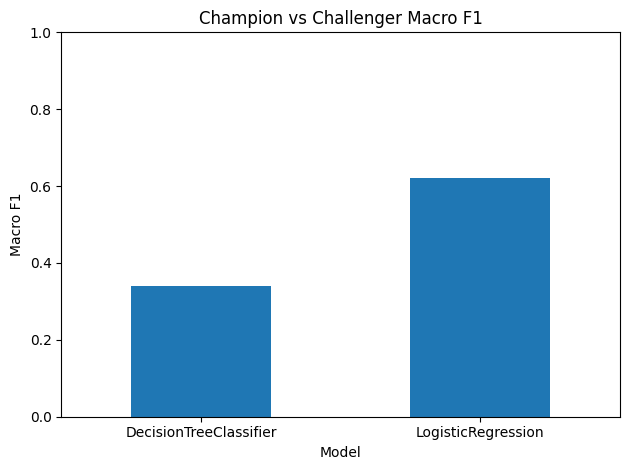

In [0]:
comparison_plot_df = comparison_df[
    [
        "algorithm",
        "test_f1_macro"
    ]
].copy()

comparison_plot_df.plot(
    kind="bar",
    x="algorithm",
    y="test_f1_macro",
    legend=False
)

plt.title(
    "Champion vs Challenger Macro F1"
)

plt.xlabel("Model")
plt.ylabel("Macro F1")
plt.xticks(rotation=0)
plt.ylim(
    0,
    max(
        comparison_plot_df[
            "test_f1_macro"
        ].max() + 0.1,
        1.0
    )
)
plt.tight_layout()
plt.show()

In [0]:
model_classes = list(
    challenger_pipeline.named_steps[
        "classifier"
    ].classes_
)

print("Model classes:")
print(model_classes)

Model classes:
['Away Win', 'Draw', 'Home Win']


In [0]:
challenger_results_df = pd.DataFrame(
    {
        "actual_result": (
            y_test.reset_index(drop=True)
        ),
        "predicted_result": (
            pd.Series(challenger_predictions)
        )
    }
)

challenger_results_df[
    "prediction_correct"
] = (
    challenger_results_df[
        "actual_result"
    ]
    == challenger_results_df[
        "predicted_result"
    ]
)
for class_index, class_name in enumerate(
    model_classes
):

    safe_class_name = (
        str(class_name)
        .strip()
        .lower()
        .replace(" ", "_")
        .replace("-", "_")
    )

    challenger_results_df[
        f"probability_{safe_class_name}"
    ] = challenger_probabilities[
        :,
        class_index
    ]
challenger_results_df[
    "prediction_confidence"
] = np.max(
    challenger_probabilities,
    axis=1
)

display(
    challenger_results_df.head(20)
)    

actual_result,predicted_result,prediction_correct,probability_away_win,probability_draw,probability_home_win,prediction_confidence
Away Win,Draw,false,0.13313846934779508,0.70415828526141,0.16270324539079506,0.70415828526141
Draw,Draw,true,0.25982679385023894,0.7349726580447252,0.005200548105035715,0.7349726580447252
Away Win,Away Win,true,0.7402076339574001,0.13105165824700876,0.12874070779559116,0.7402076339574001
Away Win,Home Win,false,0.10505155930004896,0.25402137466211205,0.640927066037839,0.640927066037839
Home Win,Home Win,true,0.2683586911829187,0.25541285512954903,0.4762284536875322,0.4762284536875322
Away Win,Home Win,false,0.059867094156737785,0.1900957537047732,0.7500371521384889,0.7500371521384889
Home Win,Away Win,false,0.6539319800565763,0.0038677013025475576,0.3422003186408762,0.6539319800565763
Draw,Home Win,false,0.30241914670396314,0.22468287878477533,0.47289797451126164,0.47289797451126164
Home Win,Home Win,true,1.0223139035240002E-5,8.93361660448634E-4,0.9990964152005161,0.9990964152005161
Draw,Home Win,false,0.3304644826588471,0.23744514771841582,0.43209036962273706,0.43209036962273706


In [0]:
challenger_results_df.to_csv(
    CHALLENGER_RESULTS_PATH,
    index=False
)

print(
    "Challenger prediction results saved to:"
)

print(CHALLENGER_RESULTS_PATH)

Challenger prediction results saved to:
/Volumes/workspace/default/football_data/challenger_test_predictions.csv


In [0]:
input_example = X_test.head(10).copy()

signature_predictions = (
    challenger_pipeline.predict(
        input_example
    )
)

challenger_signature = infer_signature(
    input_example,
    signature_predictions
)

print("MLflow model signature created.")

MLflow model signature created.


In [0]:
with mlflow.start_run(
    run_name="Logistic_Regression_Challenger"
) as challenger_run:

    challenger_run_id = (
        challenger_run.info.run_id
    )

    mlflow.log_param(
        "model_role",
        "challenger"
    )

    mlflow.log_param(
        "algorithm",
        "LogisticRegression"
    )

    mlflow.log_param(
        "penalty",
        "l2"
    )

    mlflow.log_param(
        "C",
        1.0
    )

    mlflow.log_param(
        "solver",
        "lbfgs"
    )

    mlflow.log_param(
        "max_iter",
        2000
    )

    mlflow.log_param(
        "class_weight",
        "None"
    )

    mlflow.log_param(
        "random_state",
        RANDOM_STATE
    )

    mlflow.log_param(
        "training_rows",
        len(X_train)
    )

    mlflow.log_param(
        "testing_rows",
        len(X_test)
    )

    mlflow.log_param(
        "numeric_feature_count",
        len(numeric_features)
    )

    mlflow.log_param(
        "categorical_feature_count",
        len(categorical_features)
    )

    mlflow.log_param(
        "removed_column_count",
        len(columns_to_remove)
    )

    mlflow.log_param(
        "primary_metric",
        PRIMARY_METRIC
    )

    mlflow.log_param(
        "champion_algorithm",
        champion_algorithm
    )

    mlflow.log_param(
        "champion_run_id",
        champion_run_id
    )

    mlflow.log_param(
        "champion_model_version",
        champion_version
    )

    mlflow.log_param(
        "champion_macro_f1",
        champion_macro_f1
    )

    mlflow.log_param(
        "promotion_eligible",
        promotion_eligible
    )

    for metric_name, metric_value in (
        challenger_metrics.items()
    ):

        mlflow.log_metric(
            metric_name,
            metric_value
        )

    mlflow.log_metric(
        "macro_f1_improvement",
        macro_f1_improvement
    )

    mlflow.log_metric(
        "relative_improvement_percentage",
        relative_improvement_percentage
    )

    mlflow.log_metric(
        "training_time_seconds",
        challenger_training_time
    )

    mlflow.log_metric(
        "prediction_time_seconds",
        challenger_prediction_time
    )

    mlflow.set_tag(
        "workflow",
        "champion_challenger"
    )

    mlflow.set_tag(
        "model_stage",
        "challenger"
    )

    mlflow.set_tag(
        "workflow_version",
        "version_2"
    )

    mlflow.set_tag(
        "promotion_recommendation",
        promotion_recommendation
    )

    mlflow.set_tag(
        "registration_status",
        "not_registered_yet"
    )

    logged_challenger_model = (
        mlflow.sklearn.log_model(
            sk_model=challenger_pipeline,
            artifact_path="model",
            signature=challenger_signature,
            input_example=input_example
        )
    )

print("Challenger logged successfully.")

print(
    "Challenger run ID:",
    challenger_run_id
)

print(
    "Challenger model URI:",
    logged_challenger_model.model_uri
)

2026/07/25 23:42:55 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
🔗 View Logged Model at: https://dbc-f41d3394-c5eb.cloud.databricks.com/ml/experiments/3335466781353570/models/m-a9ffd882fbd74d61a54fe5abb179eca5?o=7474658572124013


Challenger logged successfully.
Challenger run ID: 274498f94f3145bdbfcc664a5dd9a952
Challenger model URI: models:/m-a9ffd882fbd74d61a54fe5abb179eca5


In [0]:
loaded_challenger_model = (
    mlflow.sklearn.load_model(
        logged_challenger_model.model_uri
    )
)

verification_input = X_test.head(20).copy()

original_verification_predictions = (
    challenger_pipeline.predict(
        verification_input
    )
)

loaded_verification_predictions = (
    loaded_challenger_model.predict(
        verification_input
    )
)

assert np.array_equal(
    original_verification_predictions,
    loaded_verification_predictions
), (
    "Predictions from the loaded MLflow model "
    "do not match the original pipeline."
)

print(
    "Logged Challenger model verification passed."
)

Logged Challenger model verification passed.


In [0]:
challenger_information_df = pd.DataFrame(
    [
        {
            "model_role": "challenger",
            "algorithm": "LogisticRegression",
            "run_id": challenger_run_id,
            "model_uri": (
                logged_challenger_model.model_uri
            ),
            "primary_metric": PRIMARY_METRIC,
            "primary_metric_value": (
                challenger_macro_f1
            ),
            "test_accuracy": (
                challenger_metrics[
                    "test_accuracy"
                ]
            ),
            "test_precision_macro": (
                challenger_metrics[
                    "test_precision_macro"
                ]
            ),
            "test_recall_macro": (
                challenger_metrics[
                    "test_recall_macro"
                ]
            ),
            "test_f1_macro": (
                challenger_metrics[
                    "test_f1_macro"
                ]
            ),
            "test_f1_weighted": (
                challenger_metrics[
                    "test_f1_weighted"
                ]
            ),
            "training_rows": len(X_train),
            "testing_rows": len(X_test),
            "training_time_seconds": (
                challenger_training_time
            ),
            "prediction_time_seconds": (
                challenger_prediction_time
            ),
            "champion_algorithm": (
                champion_algorithm
            ),
            "champion_run_id": (
                champion_run_id
            ),
            "champion_model_version": (
                champion_version
            ),
            "champion_macro_f1": (
                champion_macro_f1
            ),
            "macro_f1_improvement": (
                macro_f1_improvement
            ),
            "relative_improvement_percentage": (
                relative_improvement_percentage
            ),
            "promotion_eligible": (
                promotion_eligible
            ),
            "promotion_recommendation": (
                promotion_recommendation
            ),
            "registration_status": (
                "pending"
            ),
            "registered_model_version": None,
            "alias_status": "not_assigned"
        }
    ]
)

display(challenger_information_df)

model_role,algorithm,run_id,model_uri,primary_metric,primary_metric_value,test_accuracy,test_precision_macro,test_recall_macro,test_f1_macro,test_f1_weighted,training_rows,testing_rows,training_time_seconds,prediction_time_seconds,champion_algorithm,champion_run_id,champion_model_version,champion_macro_f1,macro_f1_improvement,relative_improvement_percentage,promotion_eligible,promotion_recommendation,registration_status,registered_model_version,alias_status
challenger,LogisticRegression,274498f94f3145bdbfcc664a5dd9a952,models:/m-a9ffd882fbd74d61a54fe5abb179eca5,test_f1_macro,0.6222097633743984,0.6515,0.6446662708271728,0.6136885178601231,0.6222097633743984,0.6434775072688667,15999,4000,21.352007150650024,0.03511857986450195,DecisionTreeClassifier,36362b3ba7c6483f8f3f3e9d22c555da,2,0.3407115240453506,0.2814982393290478,82.62069799892615,true,PROMOTE_CHALLENGER,pending,null,not_assigned


In [0]:
challenger_information_df.to_csv(
    CHALLENGER_INFO_PATH,
    index=False
)

print(
    "Challenger run information saved to:"
)

print(CHALLENGER_INFO_PATH)

Challenger run information saved to:
/Volumes/workspace/default/football_data/challenger_run_info.csv


In [0]:
challenger_summary_df = pd.DataFrame(
    [
        {
            "comparison_metric": (
                "Macro F1"
            ),
            "champion_algorithm": (
                champion_algorithm
            ),
            "champion_macro_f1": (
                champion_macro_f1
            ),
            "challenger_algorithm": (
                "LogisticRegression"
            ),
            "challenger_macro_f1": (
                challenger_macro_f1
            ),
            "absolute_improvement": (
                macro_f1_improvement
            ),
            "relative_improvement_percentage": (
                relative_improvement_percentage
            ),
            "challenger_outperforms_champion": (
                challenger_outperforms_champion
            ),
            "promotion_eligible": (
                promotion_eligible
            ),
            "recommendation": (
                promotion_recommendation
            )
        }
    ]
)

challenger_summary_df.to_csv(
    CHALLENGER_SUMMARY_PATH,
    index=False
)

display(challenger_summary_df)

print(
    "Challenger evaluation summary saved to:"
)

print(CHALLENGER_SUMMARY_PATH)

comparison_metric,champion_algorithm,champion_macro_f1,challenger_algorithm,challenger_macro_f1,absolute_improvement,relative_improvement_percentage,challenger_outperforms_champion,promotion_eligible,recommendation
Macro F1,DecisionTreeClassifier,0.3407115240453506,LogisticRegression,0.6222097633743984,0.2814982393290478,82.62069799892615,true,true,PROMOTE_CHALLENGER


Challenger evaluation summary saved to:
/Volumes/workspace/default/football_data/challenger_evaluation_summary.csv


In [0]:
required_output_files = [
    CHALLENGER_INFO_PATH,
    CHALLENGER_RESULTS_PATH,
    CHALLENGER_SUMMARY_PATH
]

missing_output_files = [
    file_path
    for file_path in required_output_files
    if not os.path.exists(file_path)
]

assert not missing_output_files, (
    "The following Challenger output files "
    f"are missing: {missing_output_files}"
)

saved_challenger_info = pd.read_csv(
    CHALLENGER_INFO_PATH
)

saved_challenger_results = pd.read_csv(
    CHALLENGER_RESULTS_PATH
)

saved_challenger_summary = pd.read_csv(
    CHALLENGER_SUMMARY_PATH
)

assert len(saved_challenger_info) == 1
assert len(saved_challenger_results) == 4000
assert len(saved_challenger_summary) == 1

assert (
    saved_challenger_info.iloc[0][
        "algorithm"
    ]
    == "LogisticRegression"
)

print("Saved Challenger files validated successfully.")

Saved Challenger files validated successfully.


In [0]:
post_training_alias_model = (
    client.get_model_version_by_alias(
        name=REGISTERED_MODEL_NAME,
        alias=CHAMPION_ALIAS
    )
)

post_training_champion_version = str(
    post_training_alias_model.version
)

post_training_champion_run_id = str(
    post_training_alias_model.run_id
)

assert (
    post_training_champion_version
    == champion_version
)

assert (
    post_training_champion_run_id
    == champion_run_id
)

print(
    "Champion alias remains unchanged."
)

print(
    "Current Champion version:",
    post_training_champion_version
)

print(
    "Challenger has not yet been promoted."
)

Champion alias remains unchanged.
Current Champion version: 2
Challenger has not yet been promoted.


In [0]:
print("=" * 70)
print("NOTEBOOK 6 COMPLETED SUCCESSFULLY")
print("=" * 70)

print(
    "Current Champion:",
    champion_algorithm
)

print(
    "Champion version:",
    champion_version
)

print(
    "Champion Macro F1:",
    round(champion_macro_f1, 4)
)

print(
    "Challenger model:",
    "LogisticRegression"
)

print(
    "Training rows:",
    len(X_train)
)

print(
    "Testing rows:",
    len(X_test)
)

print(
    "Challenger accuracy:",
    round(
        challenger_metrics[
            "test_accuracy"
        ],
        4
    )
)

print(
    "Challenger Macro F1:",
    round(
        challenger_macro_f1,
        4
    )
)

print(
    "Absolute improvement:",
    round(
        macro_f1_improvement,
        4
    )
)

print(
    "Relative improvement:",
    round(
        relative_improvement_percentage,
        2
    ),
    "%"
)

print(
    "Promotion eligible:",
    promotion_eligible
)

print(
    "Promotion recommendation:",
    promotion_recommendation
)

print(
    "Challenger run ID:",
    challenger_run_id
)

print(
    "Challenger model URI:",
    logged_challenger_model.model_uri
)

print(
    "Saved Challenger information:",
    CHALLENGER_INFO_PATH
)

print(
    "Champion alias remains on version:",
    post_training_champion_version
)

if promotion_eligible:

    print(
        "Result: The Logistic Regression "
        "Challenger outperformed the Decision "
        "Tree Champion."
    )

    print(
        "Continue to Notebook 7 for registration "
        "and automatic promotion."
    )

else:

    print(
        "Result: The Challenger did not "
        "outperform the Champion."
    )

    print(
        "Do not continue to Notebook 7."
    )

NOTEBOOK 6 COMPLETED SUCCESSFULLY
Current Champion: DecisionTreeClassifier
Champion version: 2
Champion Macro F1: 0.3407
Challenger model: LogisticRegression
Training rows: 15999
Testing rows: 4000
Challenger accuracy: 0.6515
Challenger Macro F1: 0.6222
Absolute improvement: 0.2815
Relative improvement: 82.62 %
Promotion eligible: True
Promotion recommendation: PROMOTE_CHALLENGER
Challenger run ID: 274498f94f3145bdbfcc664a5dd9a952
Challenger model URI: models:/m-a9ffd882fbd74d61a54fe5abb179eca5
Saved Challenger information: /Volumes/workspace/default/football_data/challenger_run_info.csv
Champion alias remains on version: 2
Result: The Logistic Regression Challenger outperformed the Decision Tree Champion.
Continue to Notebook 7 for registration and automatic promotion.
